# 04 — Palermo diagnostics

Produces the Palermo-specific panels:
- `figures/PALERMO_bivariate_acf_plot.pdf` (Fig. 6) — bivariate ACF of (dry, wet) spell durations.
- `figures/PALERMO_histogram_dry_spell_fit.pdf` and `..._wet_spell_fit.pdf` (Figs. 7–8) — duration histograms with fitted pmf overlay.
- `figures/PALERMO_qqplot_dry_spell_fit.pdf` and `..._wet_spell_fit.pdf` (Figs. 9–10) — simulation-based Q-Q plots with bootstrap envelopes.
- `figures/PALERMO_proba_leaving_state.pdf` (Fig. 11) — empirical vs. hdeGPD-implied exit probabilities.

In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path().resolve().parents[1]))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from article_code.util_files import config, plotting
from article_code.util_files.spell_models import *
from article_code.util_files.statistics import *
# from article_code import statistics as st

NAME_STATION_EXAMPLE = config.STATION_EXAMPLE
list_seasons = config.SEASONS
with open(config.EXPORTS_JSON_DIR / 
    f'ecad_data_south_europe_filtered_after_1946_wet_day_thresh_{config.WET_DAY_THRESHOLD}.json') as fh:
    spells = json.load(fh)

In [2]:
spells['TOULOUSE-BLAGNAC']['dry_spell']['start_date_spell'][-1]

20250821

## Fig. 6 — Bivariate autocorrelation of (dry, wet) spell durations

WindowsPath('C:/Users/antoi/Desktop/code/companion_code_article/figures/PALERMO/PALERMO_bivariate_acf_plot.pdf')

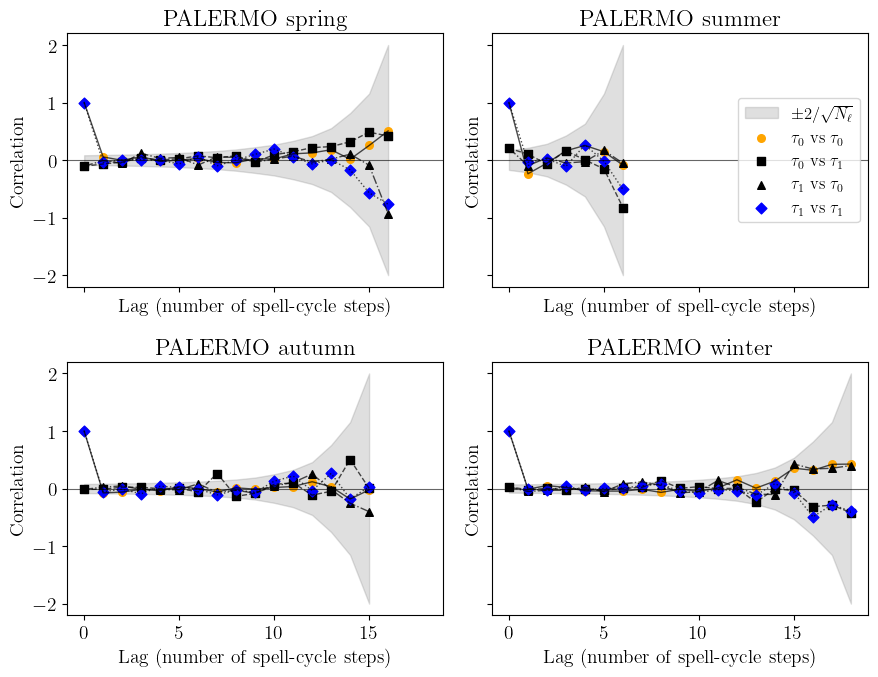

In [3]:
import numpy as np
import matplotlib.pyplot as plt

L = 20
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=14)
fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True, sharey=True)


data_by_season = split_spells_by_season_simple(spells,start_key="start_date_spell",dur_key="duration_spell")
data_per_city = build_data_per_city_per_season_per_year_couple_vector_duration_vector_date(data_by_season)
components = [
    (r"$\tau_0$ vs $\tau_0$", (0, 0), "o", "-",  "orange"),
    (r"$\tau_0$ vs $\tau_1$", (0, 1), "s", "--", "black"),
    (r"$\tau_1$ vs $\tau_0$", (1, 0), "^", "-.", "black"),
    (r"$\tau_1$ vs $\tau_1$", (1, 1), "D", ":",  "blue")]

for j, season in enumerate(list_seasons):
    ax = axes[j // 2, j % 2]
    data_city_season_by_year = data_per_city[NAME_STATION_EXAMPLE][season]
    R, Gamma, N_l, bands, Vbar = pooled_bivariate_autocorr(data_city_season_by_year, L)
    lags = np.arange(R.shape[0])
    upper = bands
    ax.fill_between(lags, -upper, upper, color="grey", alpha=0.25,
        label=r"$\pm 2/\sqrt{N_\ell}$" if j == 1 else None,)
    for label, (a, b), marker, ls, col in components:
        y = R[:, a, b]
        ax.plot(lags, y, linestyle=ls, linewidth=1.0, color="black", alpha=0.7)
        ax.scatter(lags, y, marker=marker, s=30,facecolors=col, edgecolors=col,label=label if j == 1 else None)
    ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.6)
    ax.set_title(f"{NAME_STATION_EXAMPLE} {season}")
    ax.set_xlabel("Lag (number of spell-cycle steps)")
    ax.set_ylabel("Correlation")
axes[0, 1].legend(loc="right", fontsize=12, ncol=1, frameon=True)
fig.tight_layout()
plotting.save_palermo_bivariate_acf(fig)

## Figs. 7–8 — Histograms of recorded durations with fitted pmf overlay

In [4]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parents[1]))
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from article_code.util_files import config, plotting
from article_code.util_files.spell_models import *
NAME_STATION_EXAMPLE = config.STATION_EXAMPLE

# Load saved results from notebook 01.
name_folder_save_results = (f"fit_south_europe_subset_excess_over_{config.WET_DAY_THRESHOLD}")
path_folder_save_results = config.RESULTS_FIT_DIR / name_folder_save_results
path_mixt_geom_fit_wet_spells = path_folder_save_results / "wet_spell_fit_mixt_geomresult_fit_parameters.csv"
pth_hdegpd_fit_dry_spells = path_folder_save_results / "dry_spell_fit_egpd1_excess_over_1result_fit_parameters.csv"
df_fit_wet = pd.read_csv(path_mixt_geom_fit_wet_spells)
df_fit_dry = pd.read_csv(pth_hdegpd_fit_dry_spells)
df_fit_dry["city"] = df_fit_dry["data_source"].map(lambda s:s.split()[0])
df_fit_dry["season"] = df_fit_dry["data_source"].map(lambda s:s.split()[-1])
# Load dry-spell durations for Palermo from the JSON exported by notebook 01.
with open(config.EXPORTS_JSON_DIR / 
          f'ecad_data_south_europe_filtered_after_1946_wet_day_thresh_{config.WET_DAY_THRESHOLD}.json') as fh:
    spells = json.load(fh)

WindowsPath('C:/Users/antoi/Desktop/code/companion_code_article/figures/PALERMO/PALERMO_histogram_dry_spell_fit.pdf')

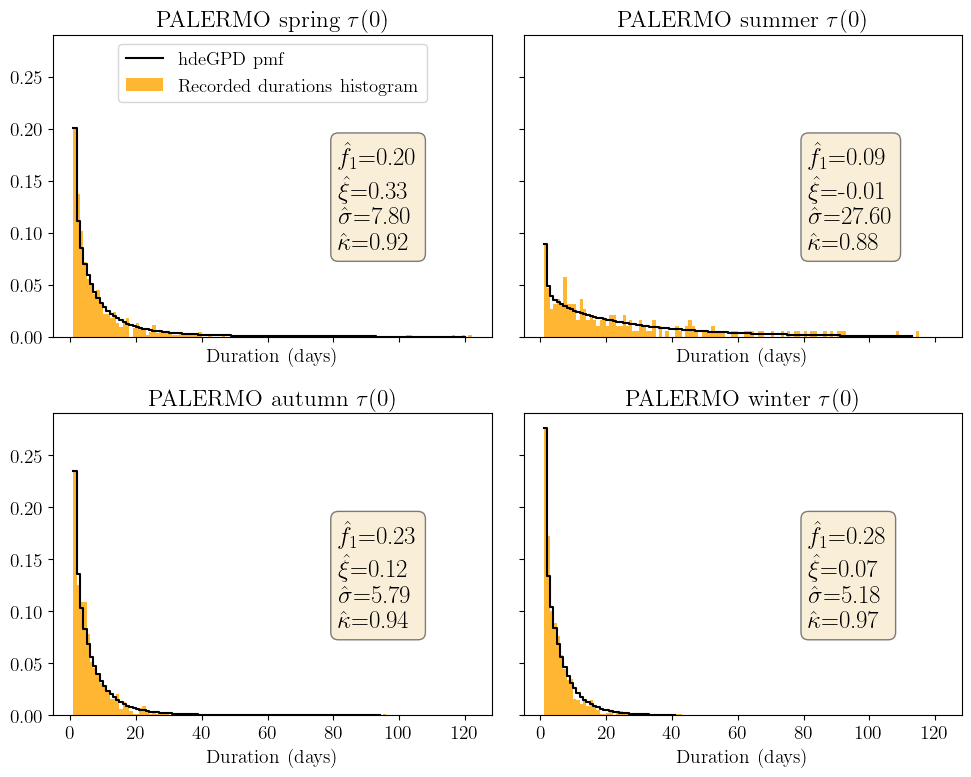

In [5]:
# Dry spells
palermo_spells = spells[NAME_STATION_EXAMPLE]['dry_spell']['duration_spell']
palermo_dates = spells[NAME_STATION_EXAMPLE]['dry_spell']['start_date_spell']
palermo_months = np.array([str(s)[4:6] for s in palermo_dates])
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
for ax, vec_month_seasons in zip(axes.flat, config.LIST_MONTH_SEASONS[1:]):
    season = vec_month_seasons[3]
    month_set = set(vec_month_seasons)
    season_mask = np.array([m in month_set for m in palermo_months])
    concatenation_neg_exc = np.array(palermo_spells)[season_mask]
    data_name = f"{NAME_STATION_EXAMPLE} {season}"

    row = df_fit_dry[df_fit_dry["data_source"] == data_name].iloc[0]
    xi, sigma, kappa = row["xi"],row["sigma"],row["kappa"]
    min_season, max_season = np.min(concatenation_neg_exc), np.max(concatenation_neg_exc)
    list_d = list(range(min_season,max_season))
    days, counts = np.unique(concatenation_neg_exc,return_counts=True)
    freqs = counts / np.sum(counts)
    ax.bar(days+0.5,freqs,width=1,label='Recorded durations histogram',color="orange",alpha=0.8)
    list_k = list()
    list_vals = list()
    f_1 = sum([s == 1 for s in concatenation_neg_exc])/len(concatenation_neg_exc) 
    cdf_fitted = make_cdf_fitted_hdeGPD_from_params(f_1, xi, sigma, kappa)

    for k in range(1,max_season-1):
        list_k += [k,k+1]
        current_val = (cdf_fitted(k) -
                        cdf_fitted(k-1))
        list_vals += [current_val,current_val]

    params_vals = [f_1,xi,sigma,kappa]
    param_names = [r"$\hat f_1$", r"$\hat \xi$", r"$\hat \sigma$", r"$\hat \kappa$"]
    ax.plot(list_k,list_vals,label="hdeGPD pmf",color="black")
    textstr = '\n'.join((name + r'=%.2f' % (val, ) for (name, val) in zip(param_names,params_vals)))
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.65, 0.65, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)    
    if season == "spring":
        ax.legend(loc="upper center",fontsize=13.5)
    ax.set_xlabel("Duration (days)")
    ax.set_title(data_name + r" $\tau{(0)}$")
    # ax.set_yscale("log")
    # ax.set_xscale("log")
fig.tight_layout()
plotting.save_palermo_dry_hist(fig)


WindowsPath('C:/Users/antoi/Desktop/code/companion_code_article/figures/PALERMO/PALERMO_histogram_wet_spell_fit.pdf')

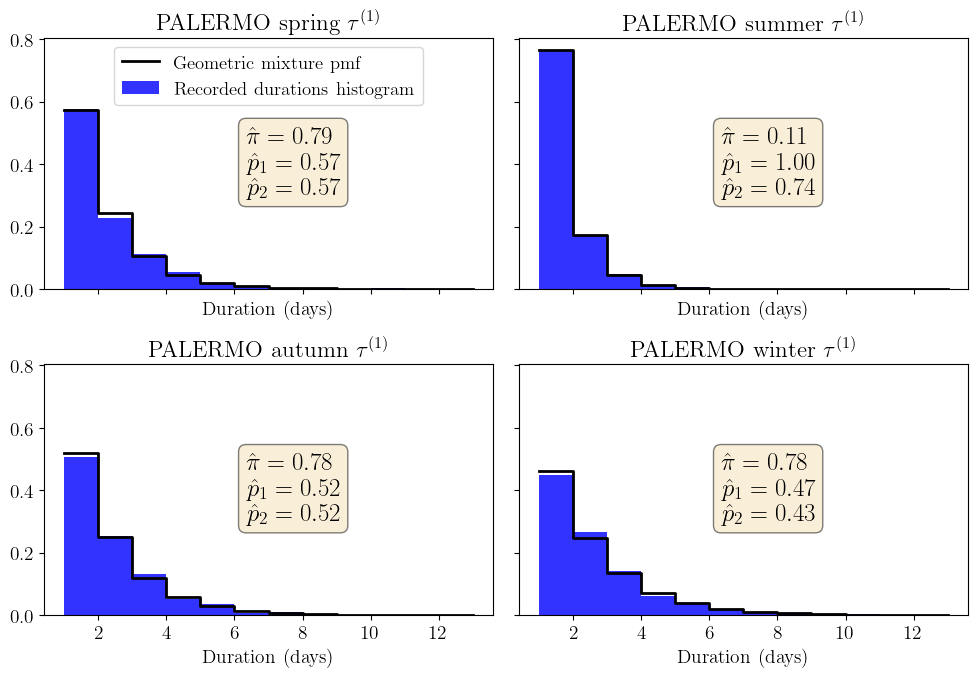

In [6]:
# Wet spells
palermo_wet_spells = spells[NAME_STATION_EXAMPLE]['wet_spell']['duration_spell']
palermo_dates = spells[NAME_STATION_EXAMPLE]['wet_spell']['start_date_spell']
palermo_months = np.array([str(s)[4:6] for s in palermo_dates])
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
for ax, vec_month_seasons in zip(axes.flat, config.LIST_MONTH_SEASONS[1:]):
    season = vec_month_seasons[3]
    month_set = set(vec_month_seasons)
    season_mask = np.array([m in month_set for m in palermo_months])
    concatenation_neg_exc = np.array(palermo_wet_spells)[season_mask]
    data_name = f"{NAME_STATION_EXAMPLE} {season}"
    days, counts = np.unique(concatenation_neg_exc, return_counts=True)
    freqs = counts / np.sum(counts)
    ax.bar(days + 0.5, freqs, width=1,label="Recorded durations histogram",color="blue", alpha=0.8)
    # ---- fit mixture geometric + plot fitted pmf as a step-like black line ----
    est = df_fit_wet[df_fit_wet["data_source"] == data_name].iloc[0].to_dict()

    k_max = int(np.max(palermo_wet_spells))
    ks = np.arange(1, k_max + 1)
    pmf_fit = mix_geom_pmf(ks, est["pi"], est["p1"], est["p2"])

    list_k, list_vals = [], []
    for k, v in zip(ks, pmf_fit):
        list_k += [k, k + 1]
        list_vals += [v, v]

    ax.plot(list_k, list_vals,label="Geometric mixture pmf",color="black", linewidth=2)

    # ---- parameter box (same look/placement as dry spell plots) ----
    txt = "\n".join([r"$\hat{\pi}=%.2f$" % est["pi"],
                    r"$\hat{p}_1=%.2f$" % est["p1"],
                    r"$\hat{p}_2=%.2f$" % est["p2"]])
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.45, 0.65, txt, transform=ax.transAxes,
            fontsize=18, verticalalignment='top', bbox=props)

    if season == "spring":
        ax.legend(loc="upper center",fontsize=13.5)
    ax.set_xlabel("Duration (days)")
    ax.set_title(data_name + r" $\tau^{(1)}$")  # change if you want a different label
fig.tight_layout()
plotting.save_palermo_wet_hist(fig)      

## Figs. 9–10 — Simulation-based Q-Q plots with bootstrap envelopes (Appendix G)

In [7]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parents[1]))
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from article_code.util_files import config, plotting
from article_code.util_files.spell_models import *
NAME_STATION_EXAMPLE = config.STATION_EXAMPLE

# Load saved results from notebook 01.
name_folder_save_results = (f"fit_south_europe_subset_excess_over_{config.WET_DAY_THRESHOLD}")
path_folder_save_results = config.RESULTS_FIT_DIR / name_folder_save_results
path_mixt_geom_fit_wet_spells = path_folder_save_results / "wet_spell_fit_mixt_geomresult_fit_parameters.csv"
pth_hdegpd_fit_dry_spells = path_folder_save_results / "dry_spell_fit_egpd1_excess_over_1result_fit_parameters.csv"
df_fit_wet = pd.read_csv(path_mixt_geom_fit_wet_spells)
df_fit_dry = pd.read_csv(pth_hdegpd_fit_dry_spells)
df_fit_dry["city"] = df_fit_dry["data_source"].map(lambda s:s.split()[0])
df_fit_dry["season"] = df_fit_dry["data_source"].map(lambda s:s.split()[-1])
# Load dry-spell durations for Palermo from the JSON exported by notebook 01.
with open(config.EXPORTS_JSON_DIR / 
          f'ecad_data_south_europe_filtered_after_1946_wet_day_thresh_{config.WET_DAY_THRESHOLD}.json') as fh:
    spells = json.load(fh)

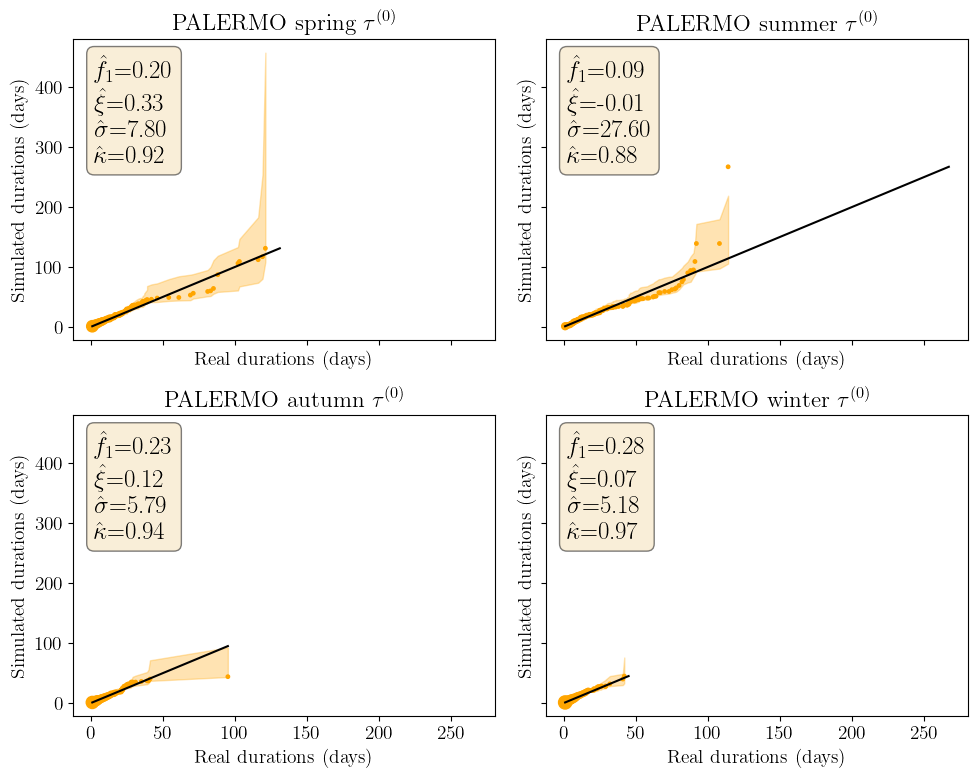

In [8]:
palermo_spells = spells[NAME_STATION_EXAMPLE]['dry_spell']['duration_spell']
palermo_dates  = spells[NAME_STATION_EXAMPLE]['dry_spell']['start_date_spell']
palermo_months = np.array([str(s)[4:6] for s in palermo_dates])

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

for ax, vec_month_seasons in zip(axes.flat, config.LIST_MONTH_SEASONS[1:]):
    season = vec_month_seasons[3]
    month_set = set(vec_month_seasons)
    season_mask = np.array([m in month_set for m in palermo_months])
    concatenation_neg_exc = np.array(palermo_spells)[season_mask]
    data_name = f"{NAME_STATION_EXAMPLE} {season}"
    row = df_fit_dry[df_fit_dry["data_source"] == data_name].iloc[0]
    xi, sigma, kappa = row["xi"], row["sigma"], row["kappa"]
    f_1 = sum(s == 1 for s in concatenation_neg_exc) / len(concatenation_neg_exc)
    generator_one_exc_dry = lambda xi=xi, sigma=sigma, kappa=kappa, proba1=f_1: \
        get_spell_length_degenerate_mixture_order_1_extgpd1(xi, sigma, kappa, proba1)
    params_vals = [f_1,xi,sigma,kappa]
    param_names = [r"$\hat f_1$", r"$\hat \xi$", r"$\hat \sigma$", r"$\hat \kappa$"]
    plotting.make_qq_plot_dry_spell(
    ax,
    data_name,
    concatenation_neg_exc,
    generator_one_exc_dry,
    params_vals,
    param_names,
    n_vectors_simulated_data=50,
    alpha_over_2_uncertainty_1=0.025)

fig.tight_layout()
plotting.save_palermo_dry_qq(fig)
plt.show()

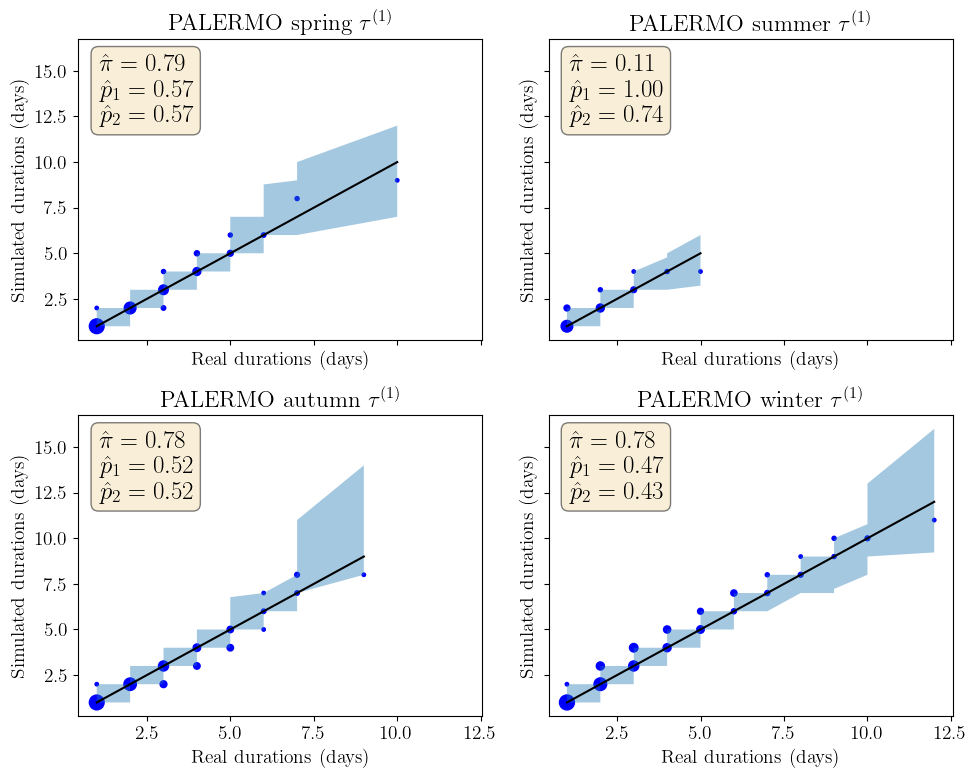

In [9]:
palermo_wet_spells = spells[NAME_STATION_EXAMPLE]['wet_spell']['duration_spell']
palermo_dates  = spells[NAME_STATION_EXAMPLE]['wet_spell']['start_date_spell']
palermo_months = np.array([str(s)[4:6] for s in palermo_dates])

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

for ax, vec_month_seasons in zip(axes.flat, config.LIST_MONTH_SEASONS[1:]):
    season = vec_month_seasons[3]
    month_set = set(vec_month_seasons)
    season_mask = np.array([m in month_set for m in palermo_months])
    concatenation_neg_exc = np.array(palermo_wet_spells)[season_mask]
    data_name = f"{NAME_STATION_EXAMPLE} {season}"
    # pre-fitted mixture-geometric parameters (loaded from CSV in notebook 01)
    row = df_fit_wet[df_fit_wet["data_source"] == data_name].iloc[0]
    pi, p1, p2 = row["pi"], row["p1"], row["p2"]
    # generator returning ONE simulated wet-spell duration (support {1,2,...})
    rng = np.random.default_rng(12345)
    generator_one_exc_wet = lambda pi=pi, p1=p1, p2=p2, rng=rng: int(
        sample_geom_mix(1, pi, p1, p2, rng=rng)[0])
    params_distribution = {"pi": pi, "p1": p1, "p2": p2}
    plotting.make_qq_plot_with_uncertainty_areas_wet_days_duration_vs_simu(
    ax,
    data_name,
    concatenation_neg_exc, 
    generator_one_exc_wet,   
    params_distribution, 
    n_vectors_simulated_data=50,
    alpha_over_2_uncertainty_1=0.025)
fig.tight_layout()
plotting.save_palermo_wet_qq(fig)
plt.show()

## Fig. 11 — Exit-state probability $q^{(0)}_d$ (empirical vs. hdeGPD-implied)

In [10]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parents[1]))
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from article_code.util_files import config, plotting
from article_code.util_files.spell_models import *
from article_code.util_files.statistics import *
NAME_STATION_EXAMPLE = config.STATION_EXAMPLE

# Load saved results from notebook 01.
name_folder_save_results = (f"fit_south_europe_subset_excess_over_{config.WET_DAY_THRESHOLD}")
path_folder_save_results = config.RESULTS_FIT_DIR / name_folder_save_results
path_mixt_geom_fit_wet_spells = path_folder_save_results / "wet_spell_fit_mixt_geomresult_fit_parameters.csv"
pth_hdegpd_fit_dry_spells = path_folder_save_results / "dry_spell_fit_egpd1_excess_over_1result_fit_parameters.csv"
df_fit_wet = pd.read_csv(path_mixt_geom_fit_wet_spells)
df_fit_dry = pd.read_csv(pth_hdegpd_fit_dry_spells)
df_fit_dry["city"] = df_fit_dry["data_source"].map(lambda s:s.split()[0])
df_fit_dry["season"] = df_fit_dry["data_source"].map(lambda s:s.split()[-1])
# Load dry-spell durations for Palermo from the JSON exported by notebook 01.
with open(config.EXPORTS_JSON_DIR / 
          f'ecad_data_south_europe_filtered_after_1946_wet_day_thresh_{config.WET_DAY_THRESHOLD}.json') as fh:
    spells = json.load(fh)

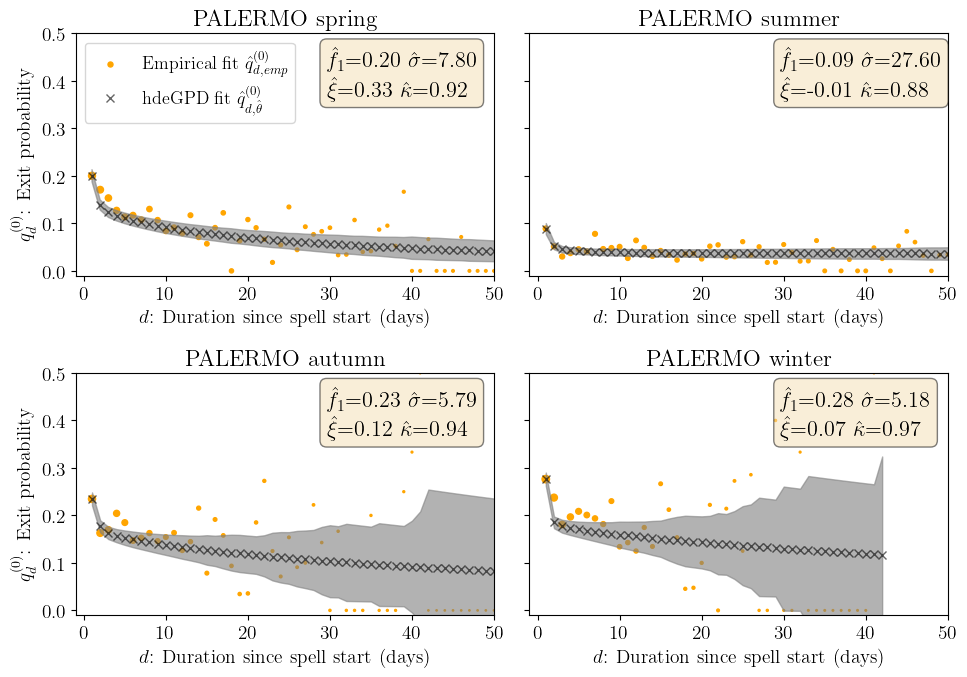

In [11]:
palermo_spells = spells[NAME_STATION_EXAMPLE]['dry_spell']['duration_spell']
palermo_dates  = spells[NAME_STATION_EXAMPLE]['dry_spell']['start_date_spell']
palermo_months = np.array([str(s)[4:6] for s in palermo_dates])

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
for j, (ax, vec_month_seasons) in enumerate(zip(axes.flat, config.LIST_MONTH_SEASONS[1:])):
    season = vec_month_seasons[3]
    month_set = set(vec_month_seasons)
    season_mask = np.array([m in month_set for m in palermo_months])
    season_durations = np.array(palermo_spells)[season_mask]
    days, probas, nb_days_state_list = get_proba_leaving_by_day(season_durations)
    days,probas,nb_days_state_list   = np.asarray(days),np.asarray(probas),np.asarray(nb_days_state_list)
    ax.scatter(days, probas, s=np.sqrt(nb_days_state_list), color='orange',
               label=r'Empirical fit $\hat q_{d,emp}^{(0)}$')
    data_name = f"{NAME_STATION_EXAMPLE} {season}"
    extract_df = df_fit_dry[df_fit_dry["data_source"] == data_name]
    xi_gpd,sigma_gpd,kappa_gpd = extract_df["xi"].item(),extract_df["sigma"].item(),extract_df["kappa"].item()
    f_1    = sum(s == 1 for s in season_durations) / len(season_durations)
    cdf_fitted = make_cdf_fitted_hdeGPD_from_params(f_1, xi_gpd, sigma_gpd, kappa_gpd)

    fitted_probas_extgpd = np.array([get_proba_leaving_state_n_kozu(cdf_fitted, d) for d in days])
    errors = fitted_probas_extgpd * (1 - fitted_probas_extgpd) / np.sqrt(nb_days_state_list)
    ax.plot(days, fitted_probas_extgpd, 'x', color='black',
            label=r'hdeGPD fit $\hat q_{d,\hat{\theta}}^{(0)}$', alpha=0.6)
    ax.fill_between(days,
                    fitted_probas_extgpd - 2 * errors,
                    fitted_probas_extgpd + 2 * errors,
                    color='gray', alpha=0.6)
    # params_vals = [f_1,xi_gpd,sigma_gpd,kappa_gpd]
    # param_names = [r"$\hat f_1$", r"$\hat \xi$", r"$\hat \sigma$", r"$\hat \kappa$"]
    # textstr = '\n'.join((name + r'=%.2f' % (val, ) for (name, val) in zip(param_names,params_vals)))
    # props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # ax.text(0.75, 0.95, textstr, transform=ax.transAxes, fontsize=16, verticalalignment='top', bbox=props)
    params_vals = [f_1, xi_gpd, sigma_gpd, kappa_gpd]
    param_names = [r"$\hat f_1$", r"$\hat \xi$", r"$\hat \sigma$", r"$\hat \kappa$"]

    items = list(zip(param_names, params_vals))
    mid = (len(items) + 1) // 2
    left_col = items[:mid]
    right_col = items[mid:]
    left_text = '\n'.join(f'{k}={v:.2f}' for k, v in left_col)
    right_text = '\n'.join(f'{k}={v:.2f}' for k, v in right_col)
    left_lines = left_text.split('\n')
    right_lines = right_text.split('\n') + [''] * (len(left_text.split('\n')) - len(right_text.split('\n')))
    textstr = '\n'.join(f'{l:<20}{r}' for l, r in zip(left_lines, right_lines))

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.6, 0.95, textstr, transform=ax.transAxes, fontsize=16,
            verticalalignment='top', bbox=props)
    ax.set_title(f"{NAME_STATION_EXAMPLE} {season}")
    ax.set_xlabel(r"$d$: Duration since spell start (days)")
    if j % 2 == 0:                       # first column
        ax.set_ylabel(r"$q_d^{(0)}$: Exit probability")
    if j == 0:                           # legend once
        ax.legend(loc='upper left', fontsize=13)

for a in axes.ravel():
    a.set_xlim(-1, 50)

plt.tight_layout()
plt.ylim(-1e-2, 0.5)
plotting.save_palermo_exit_prob(fig)
plt.show()

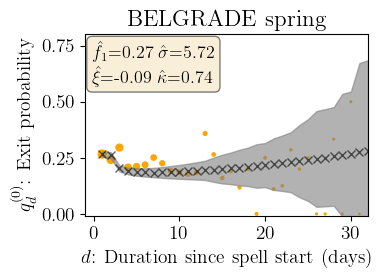

In [12]:
NAME_STATION_BELGRADE = 'BELGRADE (OBSERVATORY)'
season = "spring"

belgrade_spells = spells[NAME_STATION_BELGRADE]['dry_spell']['duration_spell']
belgrade_dates  = spells[NAME_STATION_BELGRADE]['dry_spell']['start_date_spell']
belgrade_months = np.array([str(s)[4:6] for s in belgrade_dates])

# Pick the spring months from config
vec_month_seasons = next(v for v in config.LIST_MONTH_SEASONS[1:] if v[3] == season)
month_set = set(vec_month_seasons)
season_mask = np.array([m in month_set for m in belgrade_months])
season_durations = np.array(belgrade_spells)[season_mask]

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

days, probas, nb_days_state_list = get_proba_leaving_by_day(season_durations)
days, probas, nb_days_state_list = np.asarray(days), np.asarray(probas), np.asarray(nb_days_state_list)

ax.scatter(days, probas, s=np.sqrt(nb_days_state_list), color='orange',
           label=r'Empirical fit $\hat q_{d,emp}^{(0)}$')

data_name = f"{NAME_STATION_BELGRADE} {season}"
extract_df = df_fit_dry[df_fit_dry["data_source"] == data_name]
xi_gpd, sigma_gpd, kappa_gpd = extract_df["xi"].item(), extract_df["sigma"].item(), extract_df["kappa"].item()
f_1 = sum(s == 1 for s in season_durations) / len(season_durations)
cdf_fitted = make_cdf_fitted_hdeGPD_from_params(f_1, xi_gpd, sigma_gpd, kappa_gpd)

fitted_probas_extgpd = np.array([get_proba_leaving_state_n_kozu(cdf_fitted, d) for d in days])
errors = fitted_probas_extgpd * (1 - fitted_probas_extgpd) / np.sqrt(nb_days_state_list)
ax.plot(days, fitted_probas_extgpd, 'x', color='black',
        label=r'hdeGPD fit $\hat q_{d,\hat{\theta}}^{(0)}$', alpha=0.6)
ax.fill_between(days,
                fitted_probas_extgpd - 2 * errors,
                fitted_probas_extgpd + 2 * errors,
                color='gray', alpha=0.6)

params_vals = [f_1, xi_gpd, sigma_gpd, kappa_gpd]
param_names = [r"$\hat f_1$", r"$\hat \xi$", r"$\hat \sigma$", r"$\hat \kappa$"]

items = list(zip(param_names, params_vals))
mid = (len(items) + 1) // 2
left_col = items[:mid]
right_col = items[mid:]
left_text = '\n'.join(f'{k}={v:.2f}' for k, v in left_col)
right_text = '\n'.join(f'{k}={v:.2f}' for k, v in right_col)
left_lines = left_text.split('\n')
right_lines = right_text.split('\n') + [''] * (len(left_lines) - len(right_text.split('\n')))
textstr = '\n'.join(f'{l:<20}{r}' for l, r in zip(left_lines, right_lines))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.025, 0.96, textstr, transform=ax.transAxes, fontsize=13,
        verticalalignment='top', bbox=props, family='monospace')

ax.set_title(f"{NAME_STATION_BELGRADE.split()[0]} {season}")
ax.set_xlabel(r"$d$: Duration since spell start (days)")
ax.set_ylabel(r"$q_d^{(0)}$: Exit probability")
ax.set_xlim(-1, 32)

plt.tight_layout()
plt.ylim(-1e-2, 0.8)

plotting._save(fig, f"BELGRADE_proba_leaving_state.pdf")
plt.show()

